# EDA

Aaron's first EDA based on the dynamic rhythms starter notebook

## Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests, ccf
import numpy as np
import plotly.express as px
from datetime import datetime
import geopandas as gpd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
from utils import *
import plotly.io as pio
pio.renderers.default = 'vscode'  # or 'notebook'

## Power Outage Data

This uses the eaglei data along with predictors from other sources.

The file is the `eaglei_outages_with_county_info.parquet` file, generated by the `resample_eaglei...` script. This data set includes a 6-hour cadence subset of the power outage data from 2014-2023 (we will need to manually exclude data from 2022-2023 for our test set).

In [2]:
# Load the dataset eaglei_outages_with_county_info.parquet
df_power = pd.read_parquet('../Data/eaglei_data/eaglei_outages_with_county_info.parquet')

In [3]:
# Restrict df_power to years before 2022
df_power = df_power[df_power['YEAR'] < 2022]

Below is a plot of aggregate power outages for all states and all data points in the data set. 

This is adapted from the utils file to use the already-loaded df_power dataframe.

It looks like Florida leads the nation!

In [4]:
#Set the beginning and end of the time interval
begin ='2014-01-01 00:00:00'
end='2021-12-31 00:00:00'

#Convert start_time to datetime object
start_time = datetime.strptime(begin, '%Y-%m-%d %H:%M:%S')
end_time = datetime.strptime(end, '%Y-%m-%d %H:%M:%S')

grouped = df_power[(df_power['datetime'] >= start_time) & (df_power['datetime'] <= end_time)].groupby('STUSPS').agg({'customers_out': 'sum'}).reset_index()
grouped['customers_out'] = grouped['customers_out'] / 4 #Used to be 96 for 15-minute cadence
title = "Power Outages by State"
location_col = 'state'

# Normalize colormap to the data range
max_outages = grouped['customers_out'].max()
min_outages = grouped['customers_out'].min()


# Create choropleth map
fig = px.choropleth(
    grouped,
    locations='STUSPS',
    locationmode='USA-states',
    color='customers_out',
    color_continuous_scale="OrRd",
    scope="usa",
    range_color=(min_outages, max_outages),  # Fix normalization
    title=f"{title} ({start_time.strftime('%Y-%m-%d')} to {end_time.strftime('%Y-%m-%d')})",
    labels={'customers_out': 'customers.day'}
)

# Add hover info to display total numbers
fig.update_traces(
    hovertemplate='<b>%{location}</b><br>Total Outage: %{z}<extra></extra>'
)

fig.update_geos(showcoastlines=True, coastlinecolor="Black")

fig.update_layout(
    geo=dict(
        lakecolor="lightblue",
        showlakes=True
    ),
    title_x=0.4,  # Center the title
    margin=dict(l=0, r=0, t=50, b=0),  # Minimize space between colorbar and map figure
    width=1000, height=600,  # Set figure size to (10, 6)
    title_font=dict(size=20, family='Arial, bold'),  # Set figure title font size and make it bold
    font=dict(size=14)  # Set default font size for the figure
)
    
fig.show()

In [5]:
#List all values of the Subregion variable
df_power['Subregion'].unique()

array(['SRSO', 'SRTV', 'NWPP', 'AZNM', 'SRMV', 'SPSO', 'CAMX', 'RMPA',
       'RFCE', 'FRCC', 'SRMW', 'RFCW', 'MROW', 'SPNO', 'NEWE', None,
       'RFCM', 'MROE', 'NYUP', 'NYCW', 'NYLI', 'SRVC', 'ERCT'],
      dtype=object)

I'll first be focusing on the NewEngland regional grid for the year 2020 to keep things simple-ish.

In 2020, parts of Maine experienced several significant weather-related events leading to power outages. ChatGPT reports (citing BangorDailyNews.com):

- April 2020 Snowstorm: A snowstorm dropped a foot of snow in many areas, leaving more than 250,000 Mainers without power for two days. 
- August 2020 Tropical Storm Isaias: This storm resulted in power outages affecting more than 70,000 residents for almost three days. 
- December 2020: "first a rain storm knocked out electrical service to more than 100,000 Mainers and then, four days later, another storm brought gusty winds and snow to much of the state, cutting power to more than 200,000 electricity customers. Some lost power for days."

Below is a plot (by county) of person-days (in millions) without power, followed by a time graph of person-days for 2019, 2020, and 2021, demonstrating the three unusual spikes corresponding to the above weather events, as well as another spike in late September/early October

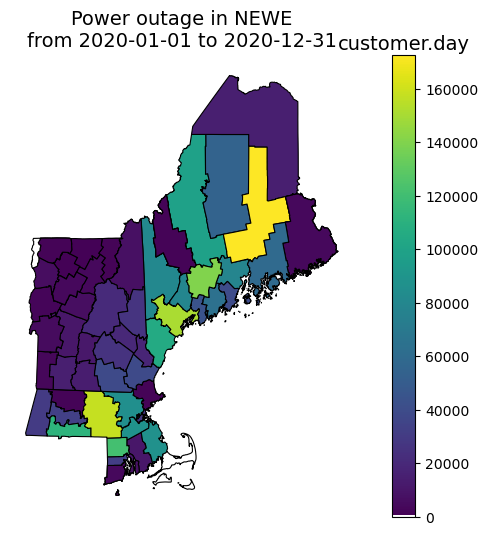

In [6]:
#Set the beginning and end of the time interval
begin ='2020-01-01 00:00:00'
end='2020-12-31 00:00:00'

#Identify the subregion and create a list of states in that subregion
Subregion = 'NEWE'
states_in_subregion = df_power[df_power['Subregion'] == Subregion]['STUSPS'].unique()

#Convert start_time to datetime object
start_time = datetime.strptime(begin, '%Y-%m-%d %H:%M:%S')
end_time = datetime.strptime(end, '%Y-%m-%d %H:%M:%S')

#Read the counties geometry file and restrict to counties to whre STUSPS is in the list states_in_subregion
counties = gpd.read_file('../Data/cb_2023_us_county_500k.zip')
counties = counties[counties['STUSPS'].isin(states_in_subregion)]

# Filter data based on time range and state
grouped = df_power[(df_power['datetime'] >= start_time) & (df_power['datetime'] <= end_time) & (df_power['Subregion'] == Subregion)].groupby(['NAME','fips_code']).agg({'customers_out': 'sum'}).reset_index()
grouped['customers_out'] = grouped['customers_out'] / 4 #Used to be 96 for 15-minute cadence

# Merge the counties with aggregated data
grouped['fips_code'] = grouped['fips_code'].astype(str)  # Ensure FIPS codes are strings
counties = counties.merge(grouped, left_on='NAME', right_on='NAME', how='left')

# Fill missing values with zero so we display it in white color
counties['customers_out'] = counties['customers_out'].fillna(0) 


# Create a custom colormap
viridis_cmap = plt.cm.viridis  # Base colormap
colors = viridis_cmap(np.linspace(0, 1, 256))  # Extract colors from viridis
colors[0] = np.array([1, 1, 1, 1])  # Set the first color (for zero values) to white
custom_cmap = ListedColormap(colors)

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
county_plot = counties.plot(column='customers_out',  # Data to visualize
                            cmap=custom_cmap,  # Colormap
                            linewidth=0.8,
                            ax=ax,
                            edgecolor='black',
                            legend=False,  # Disable automatic colorbar
                            norm=Normalize(vmin=0, vmax=counties['customers_out'].max())  # Normalize scale
                            )

# Add colorbar and set its title
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=0, vmax=counties['customers_out'].max()))
sm._A = []  # Dummy array for the ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label('Number of Customers Out', fontsize=12, labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.set_xlabel('customer.day', fontsize=14)

# Remove the vertical label
cbar.ax.set_ylabel('')

# Customize the plot
title = f"Power outage in {Subregion}\nfrom {start_time.strftime('%Y-%m-%d')} to {end_time.strftime('%Y-%m-%d')}"
ax.set_title(title, fontsize=14)
ax.axis('off')  # Turn off the axis
plt.show()

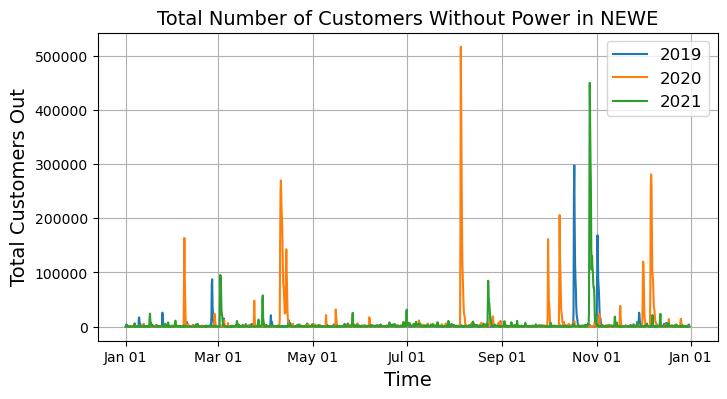

In [7]:
years = ['2019', '2020', '2021']

#Identify the subregion and create a list of states in that subregion
Subregion = 'NEWE'
states_in_subregion = df_power[df_power['Subregion'] == Subregion]['STUSPS'].unique()
    
plt.figure(figsize=(8, 4))
df_power.dropna(subset=['customers_out'], inplace=True)

# Loop through each year and plot the data
for year in years:

    # Filter df_power for the year and subregion
    df_subregion = df_power[(df_power['YEAR'] == int(year)) & (df_power['Subregion'] == Subregion)].copy()
    
    # Remove the year from 'run_start_time' to stack plots on top of each other
    df_subregion['datetime'] = df_subregion['datetime'].apply(lambda x: x.replace(year=2000))
    
    # Group by 'run_start_time' and sum the 'customers_out' for each timestamp
    df_subregion_grouped = df_subregion.groupby('datetime')['customers_out'].sum().reset_index()
    
    # Plot the time history of total customers out
    plt.plot(df_subregion_grouped['datetime'], df_subregion_grouped['customers_out'], linestyle='-', label=year)
    
plt.title(f'Total Number of Customers Without Power in {Subregion}', fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Total Customers Out', fontsize=14)
plt.grid(True)
# Format x-axis to show only month and day, remove year
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
plt.legend(fontsize=12)  # Add legend with specified font size
plt.show()

It would also be interesting to look at a couple other factors that might be related to power outages. Let's start by making a map of the Pct_Buried_Lines variable

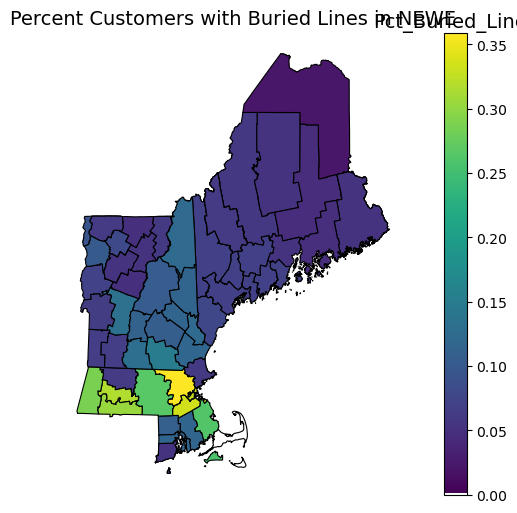

In [8]:
#Identify the subregion and create a list of states in that subregion
Subregion = 'NEWE'
states_in_subregion = df_power[df_power['Subregion'] == Subregion]['STUSPS'].unique()

#Read the counties geometry file and restrict to counties to whre STUSPS is in the list states_in_subregion
counties = gpd.read_file('../Data/cb_2023_us_county_500k.zip')
counties = counties[counties['STUSPS'].isin(states_in_subregion)]

# Filter data based on time range and state
grouped = df_power[(df_power['Subregion'] == Subregion)].groupby(['NAME','fips_code']).agg({'Pct_Buried_Lines': 'max'}).reset_index()

# Merge the counties with aggregated data
grouped['fips_code'] = grouped['fips_code'].astype(str)  # Ensure FIPS codes are strings
counties = counties.merge(grouped, left_on='NAME', right_on='NAME', how='left')

# Fill missing values with zero so we display it in white color
counties['Pct_Buried_Lines'] = counties['Pct_Buried_Lines'].fillna(0) 


# Create a custom colormap
viridis_cmap = plt.cm.viridis  # Base colormap
colors = viridis_cmap(np.linspace(0, 1, 256))  # Extract colors from viridis
colors[0] = np.array([1, 1, 1, 1])  # Set the first color (for zero values) to white
custom_cmap = ListedColormap(colors)

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
county_plot = counties.plot(column='Pct_Buried_Lines',  # Data to visualize
                            cmap=custom_cmap,  # Colormap
                            linewidth=0.8,
                            ax=ax,
                            edgecolor='black',
                            legend=False,  # Disable automatic colorbar
                            norm=Normalize(vmin=0, vmax=counties['Pct_Buried_Lines'].max())  # Normalize scale
                            )

# Add colorbar and set its title
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=0, vmax=counties['Pct_Buried_Lines'].max()))
sm._A = []  # Dummy array for the ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label('Number of Customers Out', fontsize=12, labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.set_xlabel('Pct_Buried_Lines', fontsize=14)

# Remove the vertical label
cbar.ax.set_ylabel('')

# Customize the plot
title = f"Percent Customers with Buried Lines in {Subregion}"
ax.set_title(title, fontsize=14)
ax.axis('off')  # Turn off the axis
plt.show()

Below is a plot comparing New England (NEWE) to NY City (NYCW) and NY Upstate (NYUP) for 2020.

It looks like the NEWE had more customers without power... although we should probably also consider other factors like buried power lines.

The mid-August spike appears to have occured in all three subregions. Seems like this was probably from the tropical storm that moved through many counties.

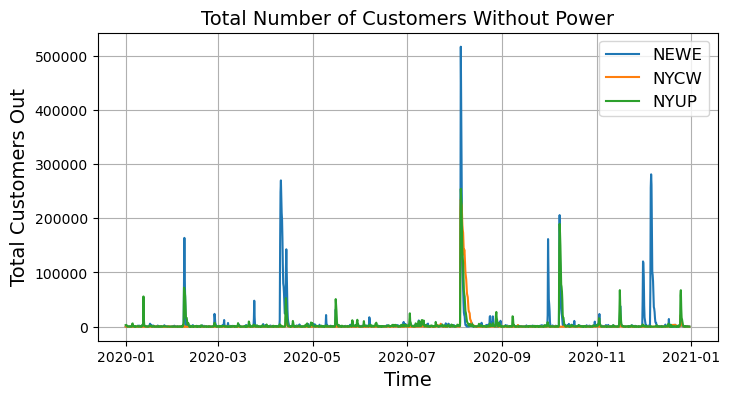

In [9]:
#Set the beginning and end of the time interval
begin ='2020-01-01 00:00:00'
end='2020-12-31 00:00:00'
subregions = ['NEWE', 'NYCW', 'NYUP']

#Convert begin and end to datetime object
start_time = datetime.strptime(begin, '%Y-%m-%d %H:%M:%S')
end_time = datetime.strptime(end, '%Y-%m-%d %H:%M:%S')


#df_power['datetime'] = pd.to_datetime(df_power['datetime'])
#df_power.dropna(subset=['customers_out'],inplace=True)

plt.figure(figsize=(8, 4))

# Loop through each subregion and plot the data
for subregion in subregions:
    # Restrict df_power to times between start_time and end_time
    df_subregion = df_power[(df_power['datetime'] >= start_time) & (df_power['datetime'] <= end_time) & (df_power['Subregion'] == subregion)]

    # Group by 'run_start_time' and sum the 'customers_out' for each timestamp
    df_subregion_grouped = df_subregion.groupby('datetime')['customers_out'].sum().reset_index()
    
    # Plot the time history of total customers out
    plt.plot(df_subregion_grouped['datetime'], df_subregion_grouped['customers_out'], linestyle='-', label=subregion)

plt.title('Total Number of Customers Without Power', fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Total Customers Out', fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)  # Add legend with specified font size
plt.show()

### NOAA's Storm Events Dataset

Below, we load `StormEvents_2014_2024.csv` as a pandas DataFrame. This DataFrame provides extensive details about storm events, including their type, location, time, and magnitude. For example, you can view all 55 types of storms in the U.S. from 2014 to 2024 by examining the `EVENT_TYPE` column, as shown below.

In [10]:
df_events = pd.read_parquet("../Data/df_events.parquet")

In [11]:
# Restrict df_events to ears prior to 2022
df_events = df_events[df_events['BEGIN_YEARMONTH'] < 202200]

In [12]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 483642 entries, 0 to 483641
Data columns (total 63 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   BEGIN_YEARMONTH                 483642 non-null  int64         
 1   BEGIN_DAY                       483642 non-null  int64         
 2   BEGIN_TIME                      483642 non-null  int64         
 3   END_YEARMONTH                   483642 non-null  int64         
 4   END_DAY                         483642 non-null  int64         
 5   END_TIME                        483642 non-null  int64         
 6   EPISODE_ID                      483642 non-null  int64         
 7   EVENT_ID                        483642 non-null  int64         
 8   STATE                           483642 non-null  object        
 9   STATE_FIPS                      483642 non-null  int64         
 10  YEAR                            483642 non-null  int64       

In [13]:
print("Different storm event types in the US from 2014 to 2024:")
df_events['EVENT_TYPE'].unique()

Different storm event types in the US from 2014 to 2024:


array(['Heavy Snow', 'Flood', 'Hail', 'Thunderstorm Wind', 'High Wind',
       'Winter Storm', 'Winter Weather', 'Drought', 'Ice Storm',
       'Tornado', 'Strong Wind', 'Flash Flood', 'Extreme Cold/Wind Chill',
       'Blizzard', 'Avalanche', 'Marine Thunderstorm Wind',
       'Cold/Wind Chill', 'Funnel Cloud', 'Heavy Rain', 'Frost/Freeze',
       'Wildfire', 'Sleet', 'Dust Storm', 'Freezing Fog', 'Waterspout',
       'Rip Current', 'Marine Hail', 'Lightning', 'Debris Flow',
       'Dense Fog', 'Astronomical Low Tide', 'High Surf', 'Coastal Flood',
       'Dust Devil', 'Hurricane (Typhoon)', 'Lake-Effect Snow',
       'Marine Strong Wind', 'Marine High Wind', 'Heat', 'Tropical Storm',
       'Lakeshore Flood', 'Seiche', 'Excessive Heat', 'Dense Smoke',
       'Marine Lightning', 'Marine Tropical Storm', 'Storm Surge/Tide',
       'Sneakerwave', 'Tsunami', 'Tropical Depression',
       'Marine Dense Fog', 'Hurricane', 'Marine Hurricane/Typhoon',
       'Marine Tropical Depression', 'Vo

Rather than try to consider all the different event types individually, I'm going to try to combine them into categories. This might help facilitate seasonal identification.

In [14]:
# Create categories of event types

snowice_types = ['Heavy Snow', 'Winter Storm', 'Winter Weather', 'Ice Storm', 'Extreme Cold/Wind Chill','Blizzard', 'Avalanche', 'Cold/Wind Chill', 'Frost/Freeze','Sleet','Freezing Fog', 'Lake-Effect Snow']

flood_types = ['Flash Flood', 'Coastal Flood','Lakeshore Flood','Debris Flow']

storm_types = ['Heavy Rain','Tropical Storm','Tropical Depression','Hail','Lightning','Marine Lightning']

hurricane_types = ['Marine Hurricane/Typhoon','Hurricane','Hurricane (Typhoon)']

heat_types = ['Excessive Heat', 'Heat']

fire_types= ['Wildfire','Dense Smoke']

wind_types = ['Marine Strong Wind', 'Marine High Wind', 'High Wind', 'Strong Wind', 'Thunderstorm Wind', 'Marine Thunderstorm Wind','Tornado','Waterspout', 'Funnel Cloud']

ocean_types = ['Rip Current','Astronomical Low Tide', 'Marine Dense Fog','Marine Tropical Depression','Marine Hail','High Surf', 'Marine Tropical Storm', 'Seiche','Storm Surge/Tide', 'Tsunami', 'Sneakerwave']

other_types = ['Drought','Dust Storm', 'Dense Fog', 'Dust Devil', 'Volcanic Ashfall']

# Add a new column to df_events that recodes EVENT_TYPE into the listed categories above
df_events['EVENT_CATEGORY'] = df_events['EVENT_TYPE'].apply(lambda x: 'SnowIce' if x in snowice_types else
                                                             'Flood' if x in flood_types else
                                                             'Storm' if x in storm_types else
                                                             'Hurricane' if x in hurricane_types else
                                                             'Heat' if x in heat_types else
                                                             'Fire' if x in fire_types else
                                                             'Wind' if x in wind_types else
                                                             'Ocean' if x in ocean_types else
                                                             'Other')

Below is code (modified from utils.py) to make bar charts of various event types throughout each month

In [ ]:
#Check if the list df_events['FIPS'] shares any values with fips_list
fips_list = df_power['fips_code'].unique()
df_events['FIPS'] = df_events['FIPS'].astype(str)
df_events = df_events[df_events['FIPS'].isin(fips_list)]


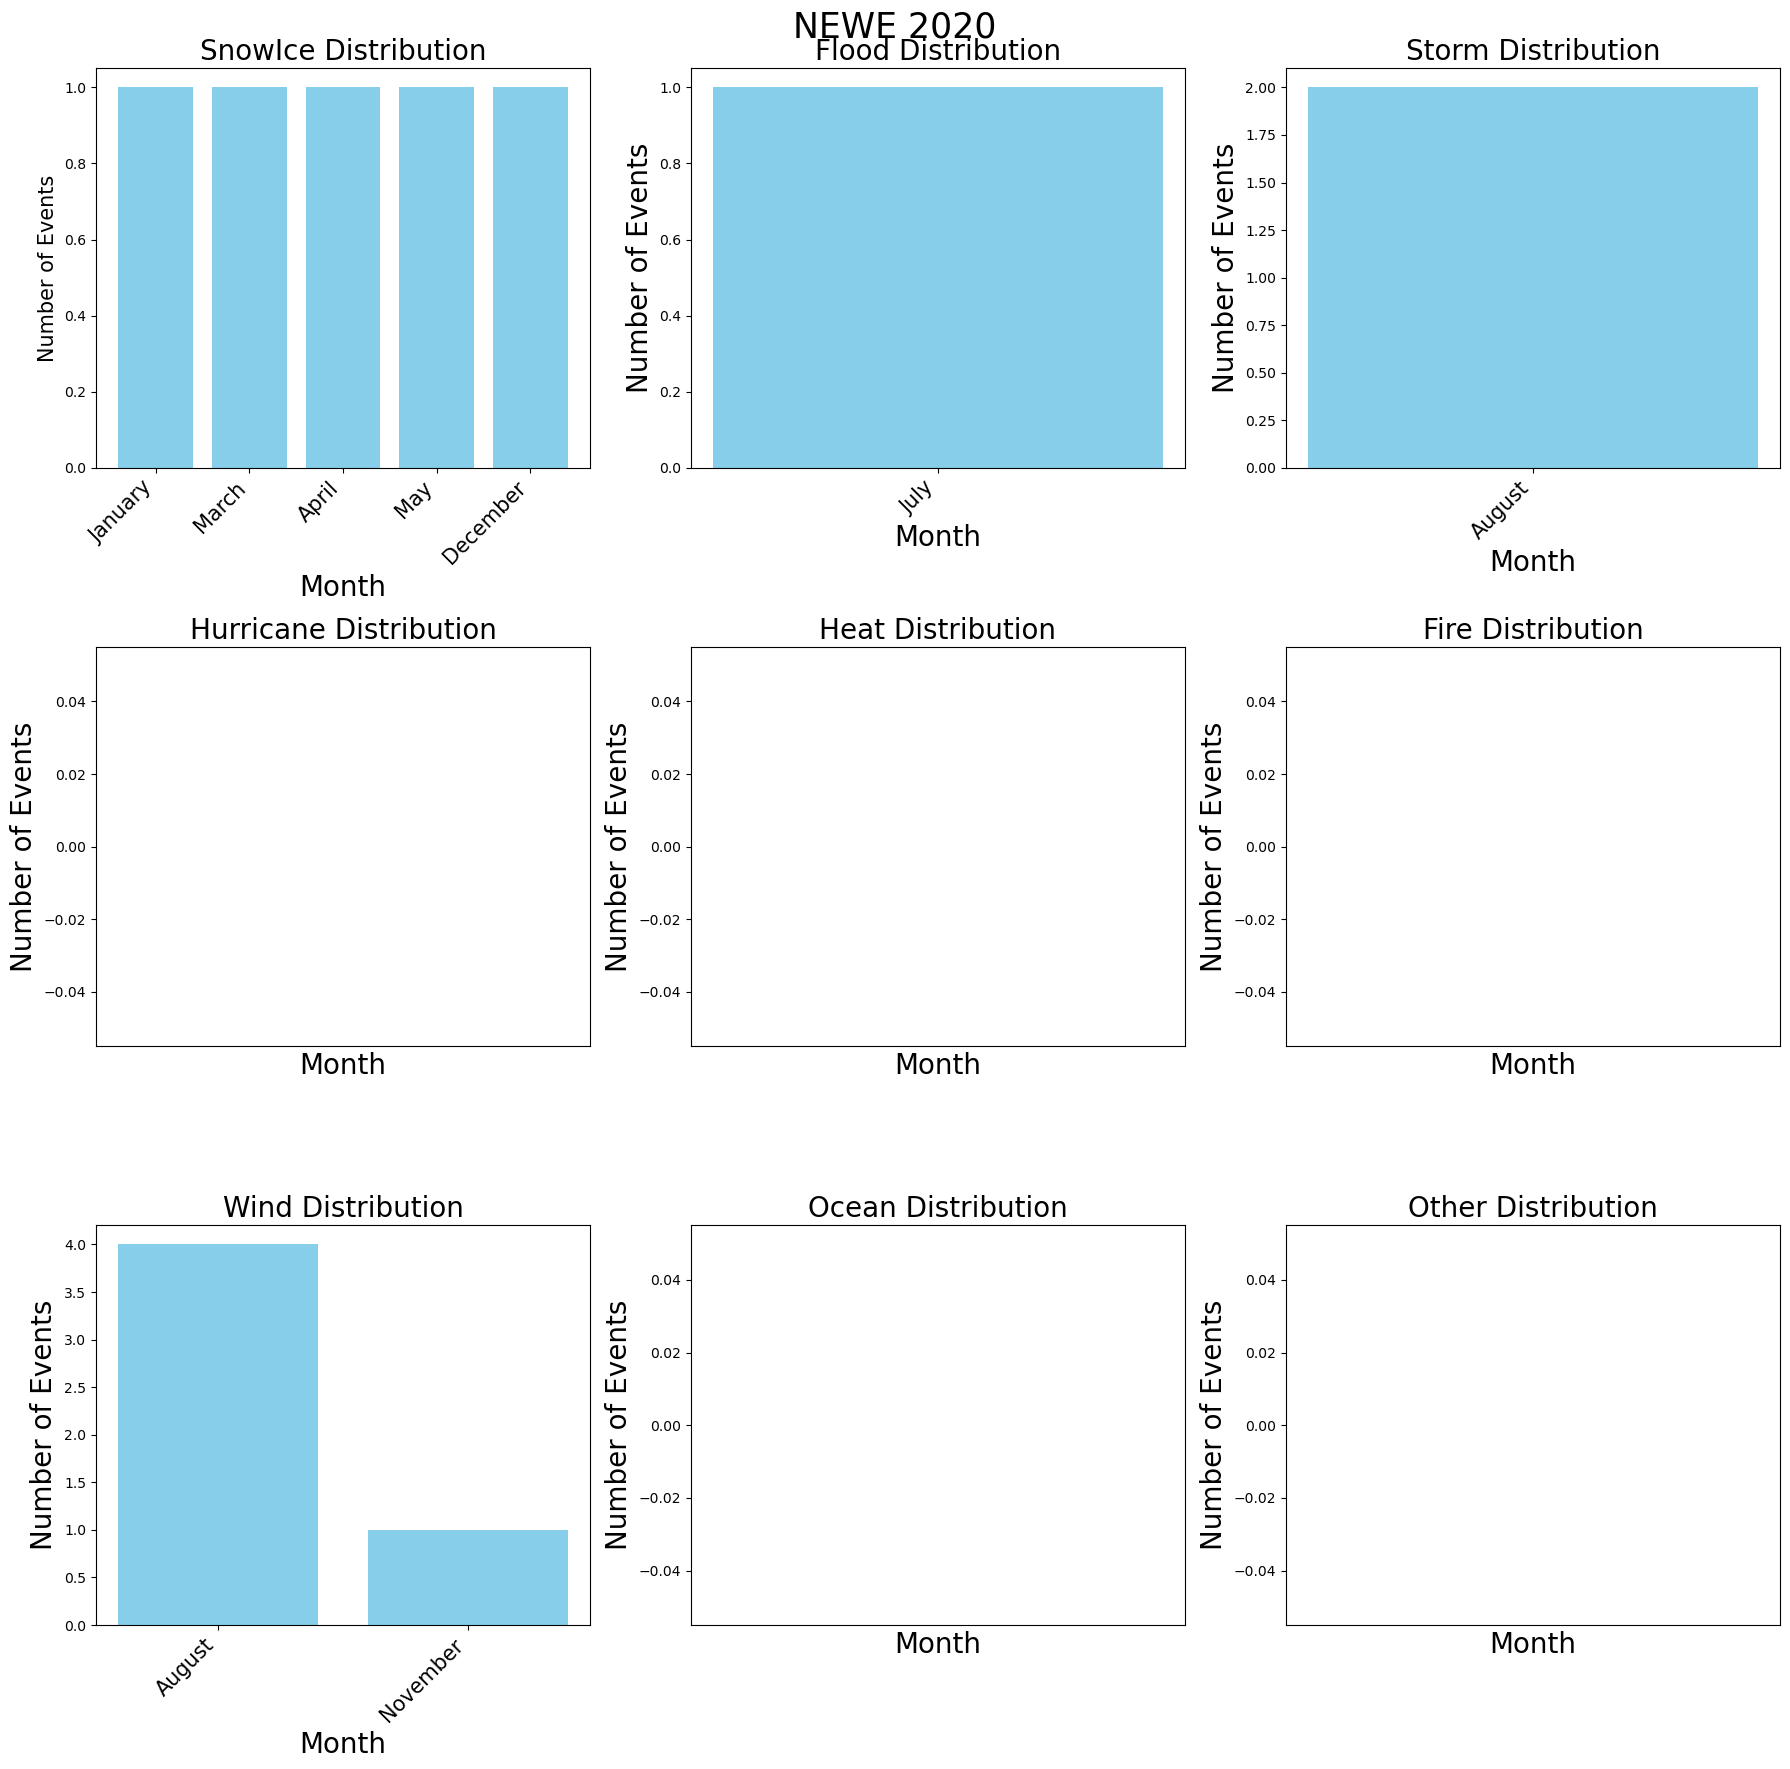

In [ ]:
state='MAINE'
subregion = 'NEWE'
all_years = False
which_year = 2020
event_types = ['SnowIce', 'Flood', 'Storm', 'Hurricane', 'Heat', 'Fire', 'Wind', 'Ocean', 'Other']

#Make a list of all FIPS values from df_power that have a Subregion value of NEWE
fips_list = df_power[df_power['Subregion'] == subregion]['fips_code'].unique()






if all_years:
    df_subregion = df_events[df_events['FIPS'].isin(fips_list)]
    title = f"{subregion} 2014-2021"
else:
    df_subregion = df_events[(df_events['FIPS'].isin(fips_list)) & (df_events['YEAR']==which_year)]
    title = f"{subregion} {which_year}" 

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 18))

# Loop through event types and create plots
for i, event in enumerate(event_types):
    # Filter data for the specific event type
    event_data = df_subregion[df_subregion['EVENT_CATEGORY'] == event]        
    
    # Group by MONTH and count events
    monthly_data = event_data.groupby('MONTH_NAME').size().reset_index(name='Event Count')

    monthly_data['MONTH_SORT'] = pd.to_datetime(monthly_data['MONTH_NAME'], format='%B')
    monthly_data = monthly_data.sort_values(by='MONTH_SORT')

    # Plot the data in a 3x3 grid
    row = i // 3
    col = i % 3

    # Plot the data
    axes[row, col].bar(monthly_data['MONTH_NAME'], monthly_data['Event Count'], color='skyblue')
    axes[row, col].set_title(f'{event} Distribution', fontsize=20)
    axes[row, col].set_xlabel('Month', fontsize=20)
    axes[row, col].set_ylabel('Number of Events', fontsize=20)
    
    axes[row, col].set_xticks(range(len(monthly_data['MONTH_NAME'].unique())))
    axes[row, col].set_xticklabels(monthly_data['MONTH_NAME'].unique(), rotation=45, ha='right', fontsize=15)

# Set common Y label
axes[0,0].set_ylabel('Number of Events', fontsize=15)

plt.suptitle(title, fontsize=25)
# Adjust layout
plt.tight_layout()
plt.show()

<br>

**Storm events severity and duration:** To understand the effects of storm events on power outages, it's crucial to consider not only the type of storm event but also its severity and duration. Below, we first create a new column in our DataFrame to represent the duration of storm events in hours. We then plot a histogram of event durations for all storm events aggregated across the entire U.S. from 2014 to 2024.

The histogram reveals that event durations are highly skewed, with many events having short durations. These short-duration events are likely inconsequential to power outages. However, it's important to note that depending on the type of storm event, even short-duration events can have a significant impact on power outages.

To further analyze this, we plot the event durations individually for each storm event type using a box plot. This visualization helps us understand the distribution of event durations for different types of storms and highlights the variability in their impact on power systems.

In summary, when assessing the impact of storm events on power outages, it's essential to consider not just the frequency of events but also their type, severity, and duration. These factors are critical in understanding and predicting the potential disruptions to power systems.

In [34]:
df_events['BEGIN_DATE'] = pd.to_datetime(
    df_events['BEGIN_YEARMONTH'].astype(str) + df_events['BEGIN_DAY'].astype(str).str.zfill(2),
    format='%Y%m%d'
)

df_events['BEGIN_DATETIME'] = pd.to_datetime(
    df_events['BEGIN_YEARMONTH'].astype(str) + df_events['BEGIN_DAY'].astype(str).str.zfill(2) + df_events['BEGIN_TIME'].astype(str).str.zfill(4),
    format='%Y%m%d%H%M'
)

df_events['END_DATE'] = pd.to_datetime(
    df_events['END_YEARMONTH'].astype(str) + df_events['END_DAY'].astype(str).str.zfill(2),
    format='%Y%m%d'
)

df_events['END_DATETIME'] = pd.to_datetime(
    df_events['END_YEARMONTH'].astype(str) + df_events['END_DAY'].astype(str).str.zfill(2) + df_events['END_TIME'].astype(str).str.zfill(4),
    format='%Y%m%d%H%M'
)

# Calculate duration in hours
df_events['DURATION_HOURS'] = (df_events['END_DATETIME'] - df_events['BEGIN_DATETIME']).dt.total_seconds() / 3600


/var/folders/gs/h69vjsl512b8200d29lxpgrc0000gn/T/ipykernel_91444/2776846866.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/gs/h69vjsl512b8200d29lxpgrc0000gn/T/ipykernel_91444/2776846866.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/gs/h69vjsl512b8200d29lxpgrc0000gn/T/ipykernel_91444/2776846866.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

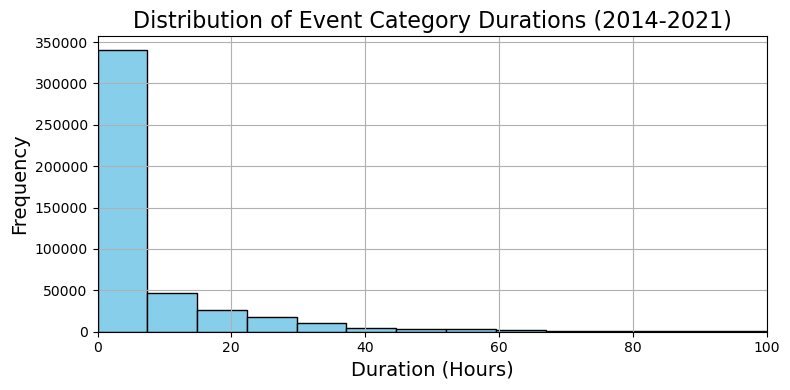

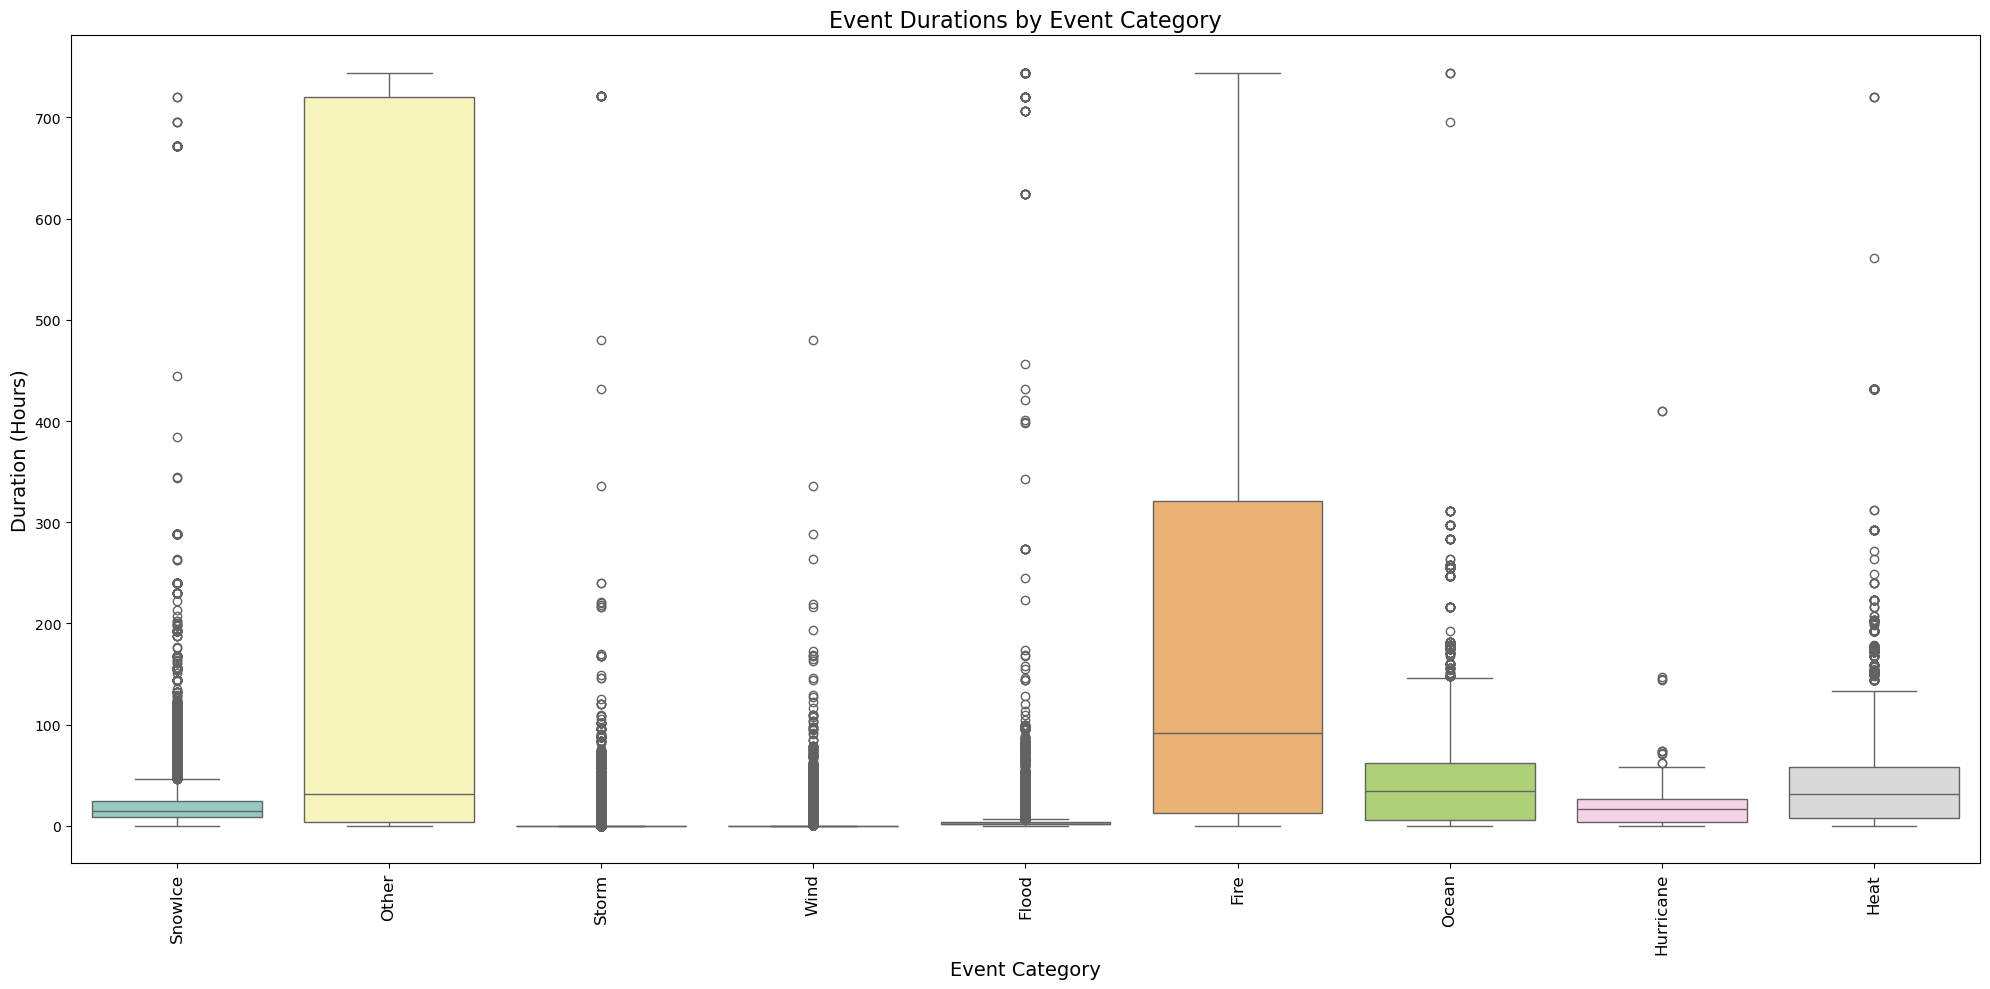

In [35]:
# Plot histogram for DURATION_HOURS
plt.figure(figsize=(8, 4))
plt.hist(df_events['DURATION_HOURS'], bins=100, color='skyblue', edgecolor='black')
plt.title('Distribution of Event Category Durations (2014-2021)', fontsize=16)
plt.xlabel('Duration (Hours)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xlim(0, 100)  # Adjust limit to focus on long-duration events
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot boxplot for DURATION_HOURS for every storm event
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_events, x='EVENT_CATEGORY', y='DURATION_HOURS', showfliers=True, palette="Set3")
plt.title('Event Durations by Event Category', fontsize=16)
plt.xlabel('Event Category', fontsize=14)
plt.ylabel('Duration (Hours)', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.tight_layout()
plt.show()

## Combined Datasets: Basic Correlation Analysis

The NOAA dataset is not inherently a time series. Instead, it has begin and end times for events. To merge the NOAA data with the eaglei data, we'll need to transform the NOAA data into a time series.

The competition provided a function ("make_ts_power") that concatenated several eaglei data sets based on a starting and ending datetime. We've already done this for all the eaglei data

The competition provided a function ("aggregate_ts") that aggregated the eaglei data over 1-hour or 1-day intervals. We've already downsampled the eaglei data into a 6-hour cadence.

Below, I'll modify the provided "make_ts_events" function to merge the eaglei data with the NOAA data.

In [71]:
# This function makes a time series from the NOAA StormEvent database
def make_ts_events(state, event_categories, start_year, start_month, start_day, end_year, end_month, end_day, df):
    """
    Construct a DataFrame with 15-minute intervals indicating event occurrence.
   
    Parameters:
    - df (pd.DataFrame): The NOAA StormEvent database.
    - state (str): The state to filter (e.g., "Texas").
    - event_categories (list): The event categories to filter (e.g., ["Storm", "Hurricane"]).
    - start_year (int): The start year for the new DataFrame.
    - start_month (int): The start month for the new DataFrame.
    - start_day (int): The start day for the new DataFrame.
    - end_year (int): The end year for the new DataFrame.
    - end_month (int): The end month for the new DataFrame.
    - end_day (int): The end day for the new DataFrame.
   
    Returns:
    - pd.DataFrame: A DataFrame with 6-hour intervals and event counts.
    """
     # Generate the time range for the new DataFrame
    start_date = datetime(start_year, start_month, start_day)
    end_date = datetime(end_year, end_month, end_day, 18, 00)  # Include the last time interval that starts at 18:00
    time_index = pd.date_range(start=start_date, end=end_date, freq='6h')
    
    # Create a new dataframe using time_index above as one of the variables
    new_df = pd.DataFrame({'time': time_index})

    # Initialize event count columns for each event type
    for category in event_categories:
        new_df[f'event_count {category}'] = 0  # Initialize event counts to 0

    # Convert BEGIN and END times into datetime objects
    df['BEGIN_DATETIME'] = pd.to_datetime(
        df['BEGIN_YEARMONTH'].astype(str) + df['BEGIN_DAY'].astype(str).str.zfill(2) +
        df['BEGIN_TIME'].astype(str).str.zfill(4), format='%Y%m%d%H%M'
    )
    df['END_DATETIME'] = pd.to_datetime(
        df['END_YEARMONTH'].astype(str) + df['END_DAY'].astype(str).str.zfill(2) +
        df['END_TIME'].astype(str).str.zfill(4), format='%Y%m%d%H%M'
    )
   
    # Filter the NOAA data for the specified state and event type
    filtered_df = df[
        (df['STATE'] == state) & 
        (df['EVENT_CATEGORY'].isin(event_categories)) & 
        (df['END_DATETIME'] >= start_date) & 
        (df['BEGIN_DATETIME'] <= end_date)
    ].copy(deep=True)
   
    # Iterate through the events and assign them to the closest time interval in the new DataFrame
    for event_category in event_categories:
        event_subset = filtered_df[filtered_df['EVENT_CATEGORY']==event_category]
        
        for _, row in event_subset.iterrows():
            event_start = row['BEGIN_DATETIME']
            event_end = row['END_DATETIME']
       
            # Round the start and end times to the nearest 6-hour interval
            event_start_rounded = event_start.round('6h')
            event_end_rounded = event_end.round('6h')
       
            # Find the indices in the new DataFrame for the rounded times
            start_idx = new_df['time'].searchsorted(event_start_rounded)
            end_idx = new_df['time'].searchsorted(event_end_rounded)
       
            # Increment the event count for the affected time intervals
            if start_idx < len(new_df) and end_idx <= len(new_df):
                new_df.loc[start_idx:end_idx, f'event_count {event_category}'] += 1
   
    # Add YEAR, MONTH, DAY columns
    new_df['YEAR'] = new_df['time'].dt.year
    new_df['MONTH'] = new_df['time'].dt.month
    new_df['DAY'] = new_df['time'].dt.day
    
    # Re-order the columns to make sure the YEAR, MONTH, DAY, time start first
    cols_order = ['YEAR', 'MONTH', 'DAY', 'time'] + [col for col in new_df.columns if col not in ['YEAR', 'MONTH', 'DAY', 'time']]
    new_df = new_df[cols_order]

    
    # Return the new_df
    return new_df    
   

In [72]:
#Use the above function to construct a NOAA timeseries dataset

ecats = ['SnowIce', 'Flood', 'Storm', 'Hurricane', 'Fire', 'Wind', 'Ocean', 'Fire', 'Other']

NOAA_timeseries_ME = make_ts_events('MAINE', ecats, 2014, 1, 1, 2021, 12, 31, df_events)

/var/folders/gs/h69vjsl512b8200d29lxpgrc0000gn/T/ipykernel_91444/3758653121.py:33: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/gs/h69vjsl512b8200d29lxpgrc0000gn/T/ipykernel_91444/3758653121.py:37: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Next, we'll restrict the df_power to Maine, then merge it with the NOAA timeseries

In [73]:
# Display 20 rows in NOAA_timeseries_ME where "event_count_SnowIce" is nonzero
NOAA_timeseries_ME

,YEAR,MONTH,DAY,time,event_count SnowIce,event_count Flood,event_count Storm,event_count Hurricane,event_count Fire,event_count Wind,event_count Ocean,event_count Other
0,2014,1,1,2014-01-01 00:00:00,15,0,0,0,0,0,0,0
1,2014,1,1,2014-01-01 06:00:00,15,0,0,0,0,0,0,0
2,2014,1,1,2014-01-01 12:00:00,15,0,0,0,0,0,0,0
3,2014,1,1,2014-01-01 18:00:00,15,0,0,0,0,0,0,0
4,2014,1,2,2014-01-02 00:00:00,20,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
11683,2021,12,30,2021-12-30 18:00:00,0,0,0,0,0,0,0,0
11684,2021,12,31,2021-12-31 00:00:00,0,0,0,0,0,0,0,0
11685,2021,12,31,2021-12-31 06:00:00,0,0,0,0,0,0,0,0
11686,2021,12,31,2021-12-31 12:00:00,0,0,0,0,0,0,0,0


In [74]:
df_power_ME = df_power[df_power['STATE']=='ME'].copy(deep=True)

# Merge NOAA_timeseries_ME with df_power_ME based on time and datetime columns
df_power_events_ME = pd.merge(NOAA_timeseries_ME, df_power_ME, left_on='time', right_on='datetime', how='left')

In [80]:
# Create a new variable in df_power_events_ME that is the sum of all columns that have the name event_count
df_power_events_ME['total_event_count'] = df_power_events_ME[[col for col in df_power_events_ME.columns if 'event_count' in col]].sum(axis=1)

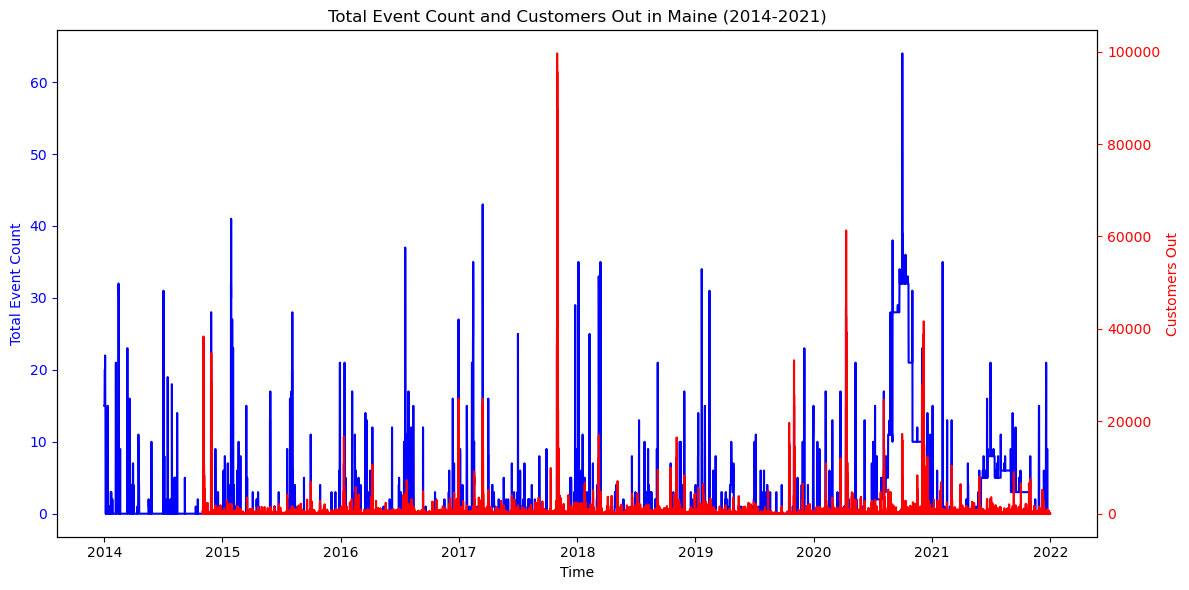

In [88]:
# Make a time series graph of df_power_events_ME for the columns 'total_event_count' and 'customers_out'. Use one y-axis for total_event_count and a separate axis for customers_out
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df_power_events_ME['time'], df_power_events_ME['total_event_count'], color='b', label='Total Event Count')
ax1.set_xlabel('Time')
ax1.set_ylabel('Total Event Count', color='b')
ax1.tick_params('y', colors='b')
ax1.set_title('Total Event Count and Customers Out in Maine (2014-2021)')
ax2 = ax1.twinx()
ax2.plot(df_power_events_ME['time'], df_power_events_ME['customers_out'], color='r', label='Customers Out')
ax2.set_ylabel('Customers Out', color='r')
ax2.tick_params('y', colors='r')
fig.tight_layout()
plt.show()

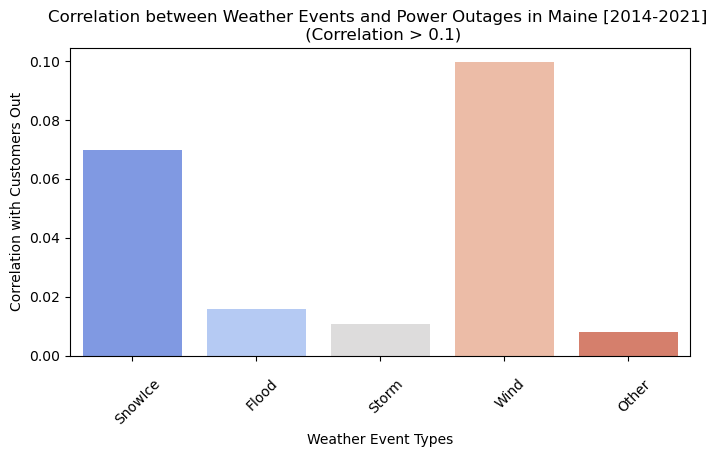

In [85]:
#Find only columns in df_power_events_ME with "event_count" or "customers_out" in the name
event_count_columns = [col for col in df_power_events_ME.columns if 'event_count' in col or col == 'customers_out']

#Remove total_event_count from event_count_columns
event_count_columns.remove('total_event_count')

correlation_with_customers_out = df_power_events_ME[event_count_columns].corr()['customers_out'].drop('customers_out')

# Filter correlations higher than 0.0
filtered_correlation = correlation_with_customers_out[correlation_with_customers_out > 0.0]

corr_list = list(filtered_correlation.index)

# Remove 'event_count' from the column names for plotting
filtered_correlation.index = filtered_correlation.index.str.replace('event_count', '')

# Split two-word names into two lines
filtered_correlation.index = filtered_correlation.index.str.replace(' ', '\n')

# Plot the filtered correlation
plt.figure(figsize=(8, 4))
sns.barplot(x=filtered_correlation.index, y=filtered_correlation.values,
            hue=filtered_correlation.index, palette='coolwarm')
plt.xlabel('Weather Event Types')
plt.ylabel('Correlation with Customers Out')
plt.title('Correlation between Weather Events and Power Outages in Maine [2014-2021] \n (Correlation > 0.1)')
plt.xticks(rotation=45)
plt.show()


To visually examine these correlations, we plot the time histories of power outages (`customers_out`) and event counts for the five event types mentioned earlier (Winter Storm, Cold/Wind Chill, Frost/Freeze, Ice Storm, and Extreme Cold/Wind Chill) for February 2021. The figure supports the correlation analysis discussed above. 

An interesting observation is that power outages lag behind storm events by a few days. This makes sense, as the buildup of a storm can eventually damage power infrastructure and cause outages. To further investigate this time delay between power outages and storm events, we calculate their correlation at different time shifts using the cross-correlation function (`ccf`) from the `statsmodels` library. 

We focus specifically on the power outage and Winter Storm time series. For this analysis, we use the combined dataset with daily increments rather than hourly increments. This choice is based on our visual inspection, which suggests that the lag between these two time series is roughly three days. The results of the `ccf` analysis confirm this observation, showing that the correlation values drop significantly after 3-4 days (shifts).

By understanding this time delay, we can better predict the impact of storm events on power outages and improve our preparedness and response strategies. This analysis highlights the importance of considering time lags in correlation studies, as they can provide valuable insights into the dynamics between extreme weather events and power system disruptions.



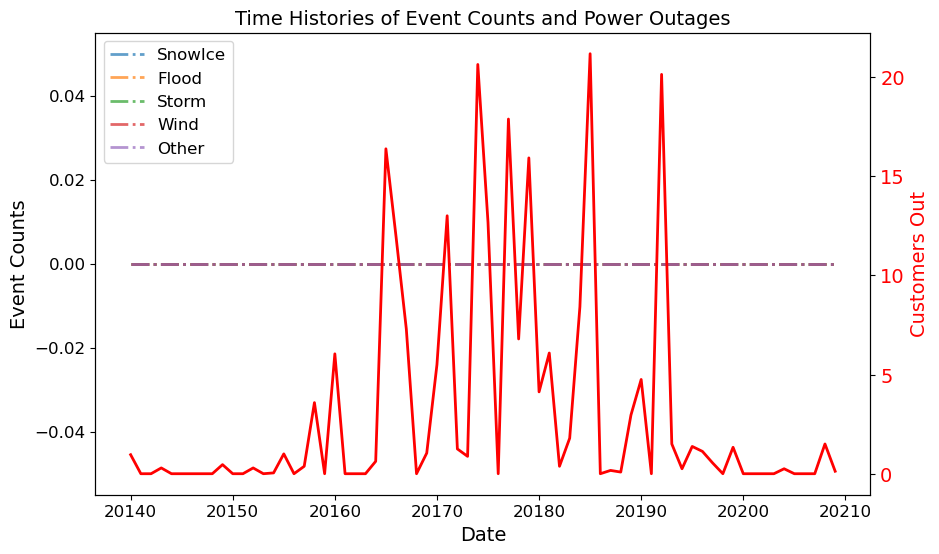

In [86]:
plot_ts_events_power(df = df_power_events_ME,
                     event_types = corr_list,
                     start_year = 2014,
                     start_month = 1,
                     start_day = 1,
                     end_year = 2021,
                     end_month = 12,
                     end_day = 31)

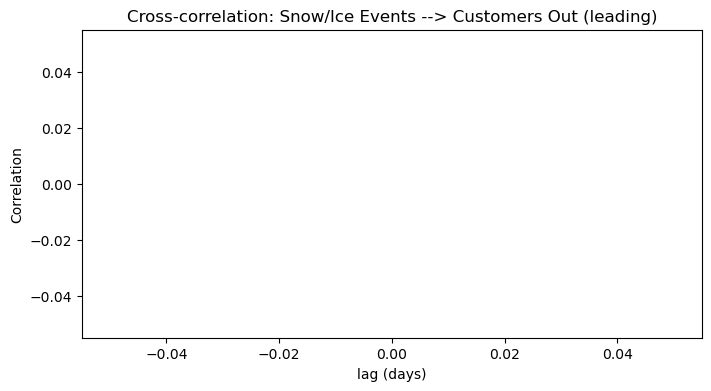

In [89]:
power_outage = df_power_events_ME['customers_out'].values
heat = df_power_events_ME['event_count SnowIce'].values

lags = 12 # check up to +/- 12 days
cc_values = ccf(heat, power_outage, adjusted = False)

plt.figure(figsize=(8 ,4))
plt.bar(range(len(cc_values[:lags])),cc_values[:lags], width = 0.8)
plt.title('Cross-correlation: Snow/Ice Events --> Customers Out (leading)')
plt.xlabel('lag (days)')
plt.ylabel('Correlation')
plt.show()